In [ ]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Load Dataset dari MyDrive/dataset ---
import pandas as pd

file_path = "/content/drive/MyDrive/dataset/International_air_passenger.csv"
data = pd.read_csv(file_path, sep=';')



Mounted at /content/drive


,Year,Month,Airlinepassengers
0,1949,1,112
1,1949,2,118
2,1949,3,132
3,1949,4,129
4,1949,5,121
...,...,...,...
139,1960,8,606
140,1960,9,508
141,1960,10,461
142,1960,11,390


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# Buat kolom Date
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))

# Set index menjadi Date
data = data.set_index('Date')

# Hapus kolom Year/Month (opsional)
data_ts = data[['Airlinepassengers']]

# Set frekuensi bulanan
data_ts = data_ts.asfreq('MS')

data_ts.head()

,Airlinepassengers
Date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


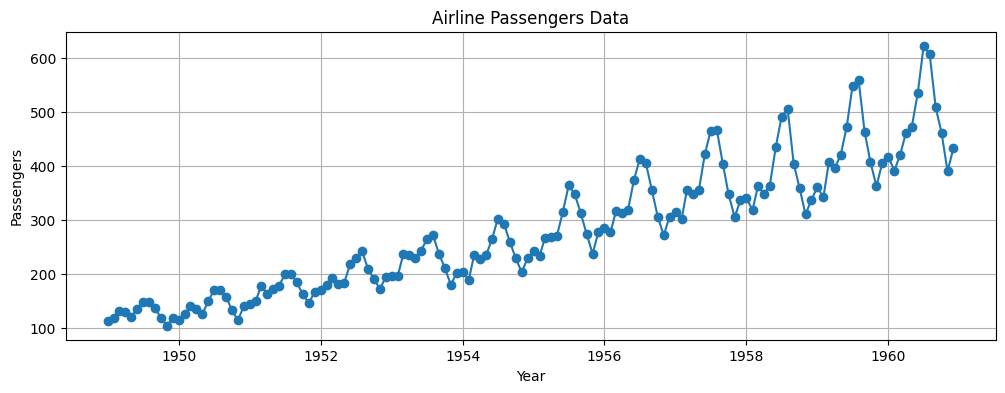

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(data_ts, marker='o')
plt.title("Airline Passengers Data")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

In [ ]:
# Salin data
df_reg = data_ts.copy()

# Trend (t)
df_reg['t'] = range(1, len(df_reg) + 1)

# Quadratic trend
df_reg['t2'] = df_reg['t']**2

# Dummy untuk Month
df_reg['Month'] = df_reg.index.month
df_reg = pd.get_dummies(df_reg, columns=['Month'], drop_first=True)

df_reg.head()

,Airlinepassengers,t,t2,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
Date,,,,,,,,,,,,,,
1949-01-01,112,1,1,False,False,False,False,False,False,False,False,False,False,False
1949-02-01,118,2,4,True,False,False,False,False,False,False,False,False,False,False
1949-03-01,132,3,9,False,True,False,False,False,False,False,False,False,False,False
1949-04-01,129,4,16,False,False,True,False,False,False,False,False,False,False,False
1949-05-01,121,5,25,False,False,False,True,False,False,False,False,False,False,False


In [ ]:
import statsmodels.api as sm

# Pisahkan X dan y
y = df_reg['Airlinepassengers']
X = df_reg.drop(columns=['Airlinepassengers'])

# Pastikan semua kolom numerik
X = X.apply(pd.to_numeric, errors='coerce')

# Tambahkan constant
X = sm.add_constant(X)

# Fit model
model_reg = sm.OLS(y.astype(float), X.astype(float)).fit()

print(model_reg.summary())

                            OLS Regression Results                            
Dep. Variable:      Airlinepassengers   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     270.8
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           2.52e-87
Time:                        08:16:42   Log-Likelihood:                -653.07
No. Observations:                 144   AIC:                             1334.
Df Residuals:                     130   BIC:                             1376.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         88.5578      8.800     10.064      0.0

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

pred_reg = model_reg.predict(X)

rmse_reg = np.sqrt(mean_squared_error(y, pred_reg))
mae_reg = mean_absolute_error(y, pred_reg)
mape_reg = np.mean(np.abs((y - pred_reg) / y)) * 100

print("Time Series Regression Error:")
print("RMSE :", rmse_reg)
print("MAE  :", mae_reg)
print("MAPE :", mape_reg)

Time Series Regression Error:
RMSE : 22.562396436084452
MAE  : 17.57874034467923
MAPE : 7.273090814186195


<Figure size 1200x400 with 0 Axes>

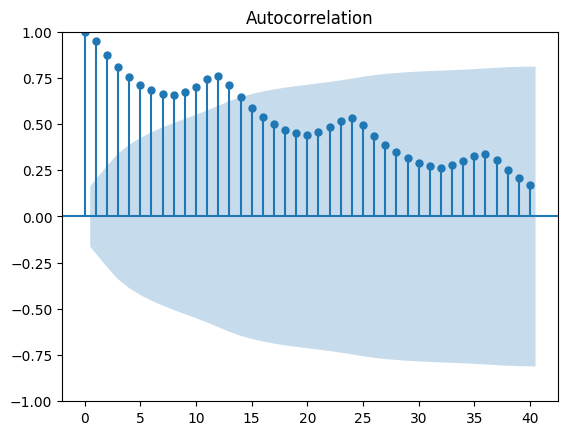

<Figure size 1200x400 with 0 Axes>

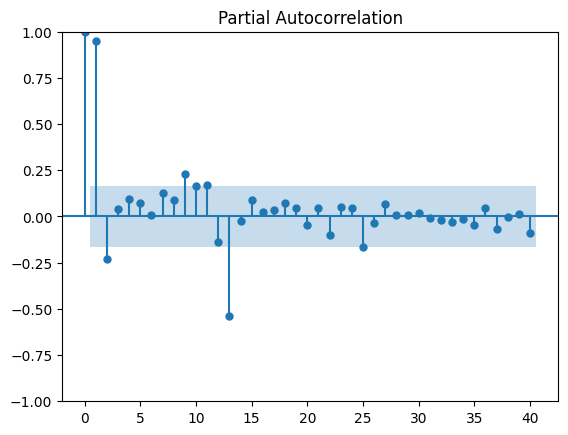

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,4))
plot_acf(data_ts, lags=40)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(data_ts, lags=40)
plt.show()

In [ ]:
import statsmodels.api as sm

model_sarima = sm.tsa.statespace.SARIMAX(
    data_ts,
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

print(model_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  Airlinepassengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -457.315
Date:                            Wed, 03 Dec 2025   AIC                            920.631
Time:                                    08:17:07   BIC                            928.917
Sample:                                01-01-1949   HQIC                           923.995
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3175      0.073     -4.342      0.000      -0.461      -0.174
ma.S.L12      -0.1123      0.097   

In [ ]:
pred_sarima = model_sarima.fittedvalues

rmse_sarima = np.sqrt(mean_squared_error(data_ts, pred_sarima))
mae_sarima = mean_absolute_error(data_ts, pred_sarima)
mape_sarima = np.mean(np.abs((data_ts['Airlinepassengers'] - pred_sarima) / data_ts['Airlinepassengers'])) * 100

print("SARIMA Error:")
print("RMSE :", rmse_sarima)
print("MAE  :", mae_sarima)
print("MAPE :", mape_sarima)

SARIMA Error:
RMSE : 16.212424349228826
MAE  : 10.282055883920314
MAPE : 4.703752579907058


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Time Series Regression', 'SARIMA'],
    'RMSE': [rmse_reg, rmse_sarima],
    'MAE': [mae_reg, mae_sarima],
    'MAPE': [mape_reg, mape_sarima]
})

comparison

,Model,RMSE,MAE,MAPE
0,Time Series Regression,22.562396,17.578740,7.273091
1,SARIMA,16.212424,10.282056,4.703753


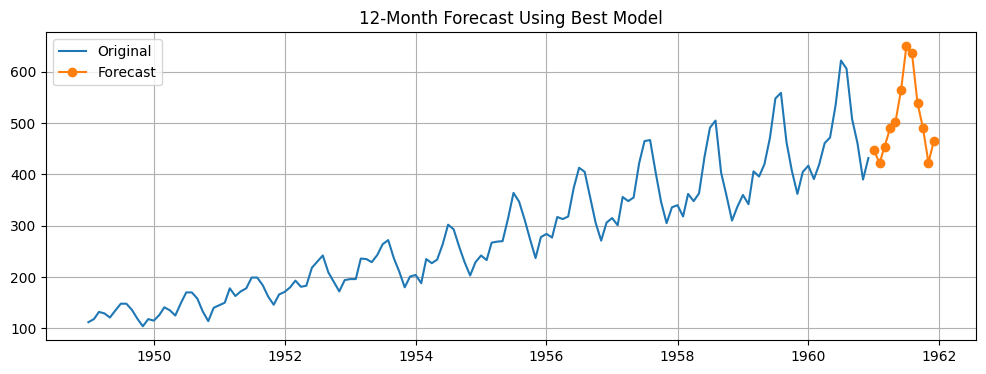

,predicted_mean
1961-01-01,447.190092
1961-02-01,422.050204
1961-03-01,453.852860
1961-04-01,489.973736
1961-05-01,502.308080
1961-06-01,564.316164
1961-07-01,649.810259
1961-08-01,636.860591
1961-09-01,539.078212
1961-10-01,491.190950


In [ ]:
forecast = model_sarima.forecast(steps=12)

plt.figure(figsize=(12,4))
plt.plot(data_ts, label="Original")
plt.plot(forecast, label="Forecast", marker='o')
plt.title("12-Month Forecast Using Best Model")
plt.legend()
plt.grid(True)
plt.show()

forecast

In [ ]:
train_size = int(len(data_ts) * 0.8)

train = data_ts.iloc[:train_size]
test  = data_ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

train.tail(), test.head()

Train size: 115
Test size: 29


(            Airlinepassengers
 Date                         
 1958-03-01                362
 1958-04-01                348
 1958-05-01                363
 1958-06-01                435
 1958-07-01                491,
             Airlinepassengers
 Date                         
 1958-08-01                505
 1958-09-01                404
 1958-10-01                359
 1958-11-01                310
 1958-12-01                337)

In [ ]:
# Copy dataset lengkap untuk regresi
df_reg_all = data_ts.copy()

# Trend variable
df_reg_all['t'] = range(1, len(df_reg_all) + 1)
df_reg_all['t2'] = df_reg_all['t']**2

# Dummy month
df_reg_all['Month'] = df_reg_all.index.month
df_reg_all = pd.get_dummies(df_reg_all, columns=['Month'], drop_first=True)

# Split train & test untuk regresi berdasarkan index
df_reg_train = df_reg_all.iloc[:train_size]
df_reg_test  = df_reg_all.iloc[train_size:]

# Pisahkan X dan y
y_train = df_reg_train['Airlinepassengers']
X_train = df_reg_train.drop(columns=['Airlinepassengers'])
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_train = sm.add_constant(X_train)

y_test = df_reg_test['Airlinepassengers']
X_test = df_reg_test.drop(columns=['Airlinepassengers'])
X_test = X_test.apply(pd.to_numeric, errors='coerce')
X_test = sm.add_constant(X_test)

# Fit model
model_reg_tt = sm.OLS(y_train.astype(float), X_train.astype(float)).fit()

# Predict for test
pred_reg_test = model_reg_tt.predict(X_test)

pred_reg_test.head()

,0
Date,
1958-08-01,454.897912
1958-09-01,423.896654
1958-10-01,393.673174
1958-11-01,368.11636
1958-12-01,395.448435


In [ ]:
rmse_reg_test = np.sqrt(mean_squared_error(y_test, pred_reg_test))
mae_reg_test  = mean_absolute_error(y_test, pred_reg_test)
mape_reg_test = np.mean(np.abs((y_test - pred_reg_test) / y_test)) * 100

print("Regression Test Error:")
print("RMSE:", rmse_reg_test)
print("MAE :", mae_reg_test)
print("MAPE:", mape_reg_test)

Regression Test Error:
RMSE: 43.540709051618364
MAE : 38.20802769267102
MAPE: 9.081501698418528


In [ ]:
model_sarima_tt = sm.tsa.statespace.SARIMAX(
    train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# Forecast sepanjang jumlah test
sarima_forecast = model_sarima_tt.forecast(steps=len(test))

sarima_forecast.head()


,predicted_mean
1958-08-01,489.136378
1958-09-01,428.053134
1958-10-01,372.278810
1958-11-01,331.166273
1958-12-01,362.745219


In [ ]:
rmse_sarima_test = np.sqrt(mean_squared_error(test, sarima_forecast))
mae_sarima_test  = mean_absolute_error(test, sarima_forecast)
mape_sarima_test = np.mean(np.abs((test['Airlinepassengers'] - sarima_forecast) / test['Airlinepassengers'])) * 100

print("SARIMA Test Error:")
print("RMSE:", rmse_sarima_test)
print("MAE :", mae_sarima_test)
print("MAPE:", mape_sarima_test)

SARIMA Test Error:
RMSE: 30.580048420345445
MAE : 24.05921513630113
MAPE: 5.151667278841126


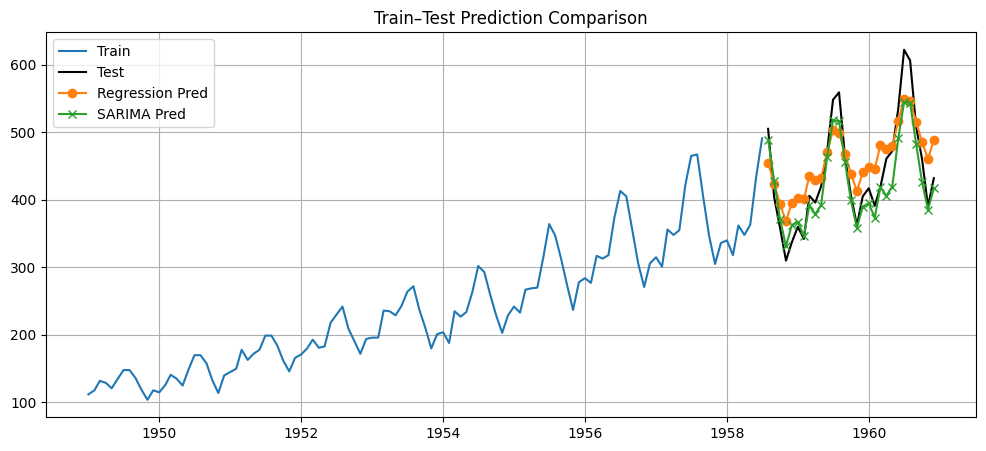

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color='black')

plt.plot(test.index, pred_reg_test, label="Regression Pred", marker='o')
plt.plot(test.index, sarima_forecast, label="SARIMA Pred", marker='x')

plt.title("Train–Test Prediction Comparison")
plt.legend()
plt.grid()
plt.show()
